In [2]:
import csv
import sqlite3
import re
import difflib
import pandas as pd
import numpy as np
from rapidfuzz import fuzz, process, utils, distance
from collections import Counter
from itertools import product
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
connection = sqlite3.connect("all_hiski_records.sqlite3")
cursor = connection.cursor()

In [4]:
csv_file = "muuttaneet_1805-1836_ap/autods_ahlainen_muuttaneet_1805-1836_ap_3_left_5.csv"

In [5]:
lines = []
with open(csv_file, "r") as file:
    reader = csv.reader(file, delimiter=",")
    for line in reader:
        lines.append([word.strip(' "') for word in line])

col_counter = Counter()
lens = []
for line in lines:
    lens.append(len(line))

col_counter.update(lens)
col_counter.most_common()

[(6, 21)]

In [6]:
another_csv_file = "autods_hameenkyro_muuttaneet_1891-1912_ap_3_left_5.csv"

lines = []
with open(another_csv_file, "r") as file:
    reader = csv.reader(file, delimiter=",")
    for line in reader:
        lines.append([word.strip(' "') for word in line])

col_counter = Counter()
lens = []
for line in lines:
    lens.append(len(line))

col_counter.update(lens)
col_counter.most_common()

[(9, 15)]

In [ ]:
ahlainen = cursor.execute("SELECT * FROM immigrated WHERE parish_id=1;").fetchall()
ahlainen_table_cols = cursor.execute("SELECT name FROM PRAGMA_TABLE_INFO('immigrated');").fetchall()
ahlainen_table_cols = [c[0] for c in ahlainen_table_cols]

nilsia = cursor.execute("SELECT * FROM immigrated WHERE parish_id=1;").fetchall()
nilsia_table_cols = cursor.execute("SELECT name FROM PRAGMA_TABLE_INFO('immigrated');").fetchall()
nilsia_table_cols = [c[0] for c in nilsia_table_cols]

ahlainen_strings = [" ".join([str(w).strip(" ") for w in row if w != 0 and w != None and w != ""]) for row in ahlainen]
nilsia_strings = [" ".join([str(w).strip(" ") for w in row if w != 0 and w != None and w != ""]) for row in nilsia]

ahlainen_dicts = [
    {k: v for k, v in zip(ahlainen_table_cols, row)}
    for row in ahlainen
]
nilsia_dicts = [
    {k: v for k, v in zip(nilsia_table_cols, row)}
    for row in nilsia
]

In [10]:
csv_files = !ls "muuttaneet_1805-1836_ap"

In [11]:
files_in = [f for f in csv_files if "left" in f]

files_in_as_lists = []
for i in range(len(files_in)):
    file = files_in[i].split("_")
    file[5] = int(file[5])
    tmp = file[7].split(".")
    file[7] = int(tmp[0])
    file.append(tmp[1])

    files_in_as_lists.append(file)

In [12]:
files_in_sorted = [f[1] for f in sorted(
    [*zip(files_in_as_lists, files_in)],
    key=lambda x: x[0]
)]

In [13]:
" ".join([str(c).replace("\\K", " ") for c in ahlainen[0][1:]])

'0 0 0 17 2 1805 Norrmark Hvittisbofjerd  Tp. Petter född. 1771. Mattss.  None None 1 None pehr mats '

In [14]:
pages = []
pages_str = []
for file_name in files_in_sorted:
    with open("muuttaneet_1805-1836_ap/" + file_name, "r") as file:
        reader = csv.reader(file, delimiter=",")

        lines = []
        for line in reader:
            lines.append([word.strip(' "') for word in line])

        pages.append(lines)
        pages_str.append([" ".join(line).strip() for line in lines])

pages_joined_str = ["\n".join(p) for p in pages_str]

In [15]:
page_matches = {file_name: [] for file_name in files_in_sorted}
event_page_match = {e["event_id"]: [] for e in ahlainen_dicts}

for event in ahlainen_dicts[:10]:
    query = " ".join([
        str(event["arr_day"]),
        str(event["arr_month"]),
        str(event["arr_year"]),
        event["profession"].replace("\\K", " "),
        event["first_name"].replace("\\K", " "),
        event["patronym"].replace("\\K", " "),
        event["last_name"].replace("\\K", " "),
        event["source"].replace("\\K", " "),
    ]).strip()

    match = process.extract(
        query,
        pages_str,
    )

    for m in match:
        page_matches[files_in_sorted[m[2]]].append(
            (event["event_id"], m[1])
        )
        event_page_match[event["event_id"]].append(
            (files_in_sorted[m[2]], m[1])
        )

In [16]:
page_matches

{'autods_ahlainen_muuttaneet_1805-1836_ap_3_left_5.csv': [(162552, 0.0),
  (162553, 0.0),
  (162554, 0.0),
  (162555, 0.0),
  (162556, 0.0),
  (162557, 0.0),
  (162558, 0.0),
  (162559, 0.0),
  (162560, 0.0),
  (162561, 0.0)],
 'autods_ahlainen_muuttaneet_1805-1836_ap_4_left_5.csv': [(162552, 0.0),
  (162553, 0.0),
  (162554, 0.0),
  (162555, 0.0),
  (162556, 0.0),
  (162557, 0.0),
  (162558, 0.0),
  (162559, 0.0),
  (162561, 0.0)],
 'autods_ahlainen_muuttaneet_1805-1836_ap_4_left_6.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_5_left_5.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_5_left_6.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_6_left_5.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_7_left_5.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_8_left_5.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_9_left_6.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_10_left_5.csv': [],
 'autods_ahlainen_muuttaneet_1805-1836_ap_11_left_5.csv': [],
 'autods_ahl

In [17]:
for event in ahlainen_dicts:
    s = event["first_name"].replace("\\K", " ")
    f = fuzz.partial_ratio_alignment(
        "född.",
        s
    )
    if f.score >= 75:
        event["first_name"] = s[f.src_start:f.dest_start]
        event["birthday"] = s[f.dest_end:]
    else:
        event["first_name"] = s

In [18]:
events = {event["event_id"]: " ".join([
    str(event["arr_day"]) + " " + str(event["arr_month"]),
    event["profession"].strip()
    + " " + event["first_name"].strip()
    + " " + event["patronym"].strip()
    + " " + event["last_name"].strip(),
    event.get("birthday", "").strip(),
    event["source"].strip(),
]) for event in ahlainen_dicts}

In [19]:
page_matches = {file_name: [] for file_name in files_in_sorted}
event_page_match = {e["event_id"]: [] for e in ahlainen_dicts}

for event_id, event in events.items():
    match = process.extract(
        event,
        pages_joined_str,
        scorer=fuzz.partial_ratio,
        score_cutoff=50
    )

    for m in match:
        page_matches[files_in_sorted[m[2]]].append(
            (event_id, m[1])
        )
        event_page_match[event_id].append(
            (files_in_sorted[m[2]], m[1])
        )

In [20]:
row_matches = {file_name: [] for file_name in page_matches.keys()}

i = 0
for file_name, matches in row_matches.items():
    tmp_lines = pages_str[i][:]
    i += 1

    tmp_events = sorted(
        page_matches[file_name],
        key=lambda x: x[1], reverse=True
    )

    while len(tmp_events) > 0 and len(tmp_lines) > 0:
        event_id = tmp_events.pop(0)[0]
        match = process.extractOne(
            events[event_id],
            tmp_lines,
            scorer=fuzz.partial_ratio,
            score_cutoff=60
        )
        if match:
            matches.append(
                (event_id, tmp_lines.pop(match[2]), match[1])
            )

In [21]:
for event_id, ocr, similarity in sorted(row_matches["autods_ahlainen_muuttaneet_1805-1836_ap_5_left_5.csv"], key=lambda x: x[0]):
    print(
        f"event_id: {event_id}",
        f"Annotated: {events[event_id]}",
        f"OCR read: {ocr}",
        f"Similarity: {similarity}",
        "---",
        sep="\n"
    )

event_id: 162593
Annotated: 30 10  Anna Fredr. Joh.dr.  23.9. 1786. Björneborgs l.förs.
OCR read: 34. 18/10 01 Annaord. Joh:o. 17/9 86. Työmies borgs L. ty Antan anmärkning
Similarity: 60.17699115044248
---
event_id: 162594
Annotated: 6 10  Johan And.s. Nummelin 21.7.1776. Björneborgs stad
OCR read: 36 18/10 05. Johan And. J: Numelin 17/1 76. Binnbergs Ilavi utan vidare ännu ärkom
Similarity: 71.55963302752293
---
event_id: 162595
Annotated: 5 12 p. Caisa Johansdr  3.7.1764. Gammelby
OCR read: 144. 35/12 05 Pi; Caisa Johan dr 73/9 67. Gammelby- it an anematoni isän luht. krif
Similarity: 71.42857142857143
---
event_id: 163378
Annotated: 11 11 hu. Anna Johansdr   Gammelby
OCR read: er n:o 6/1 Pig. Lena Johans dr 2/10 64 Gammelby. utan anmärkning.
Similarity: 70.58823529411764
---
event_id: 163775
Annotated: 27 4 drg. Adolph Johanss.   
OCR read: 33. 18/10 05. Dy: Adolph Johansson 17387 Sykais. utan ännärkning.
Similarity: 64.28571428571428
---


In [22]:
sum([len(x) for x in row_matches.values()])

1562

In [23]:
sum([len(p) for p in pages_str])

2844

Text(208.09722222222223, 0.5, 'ocr ranges')

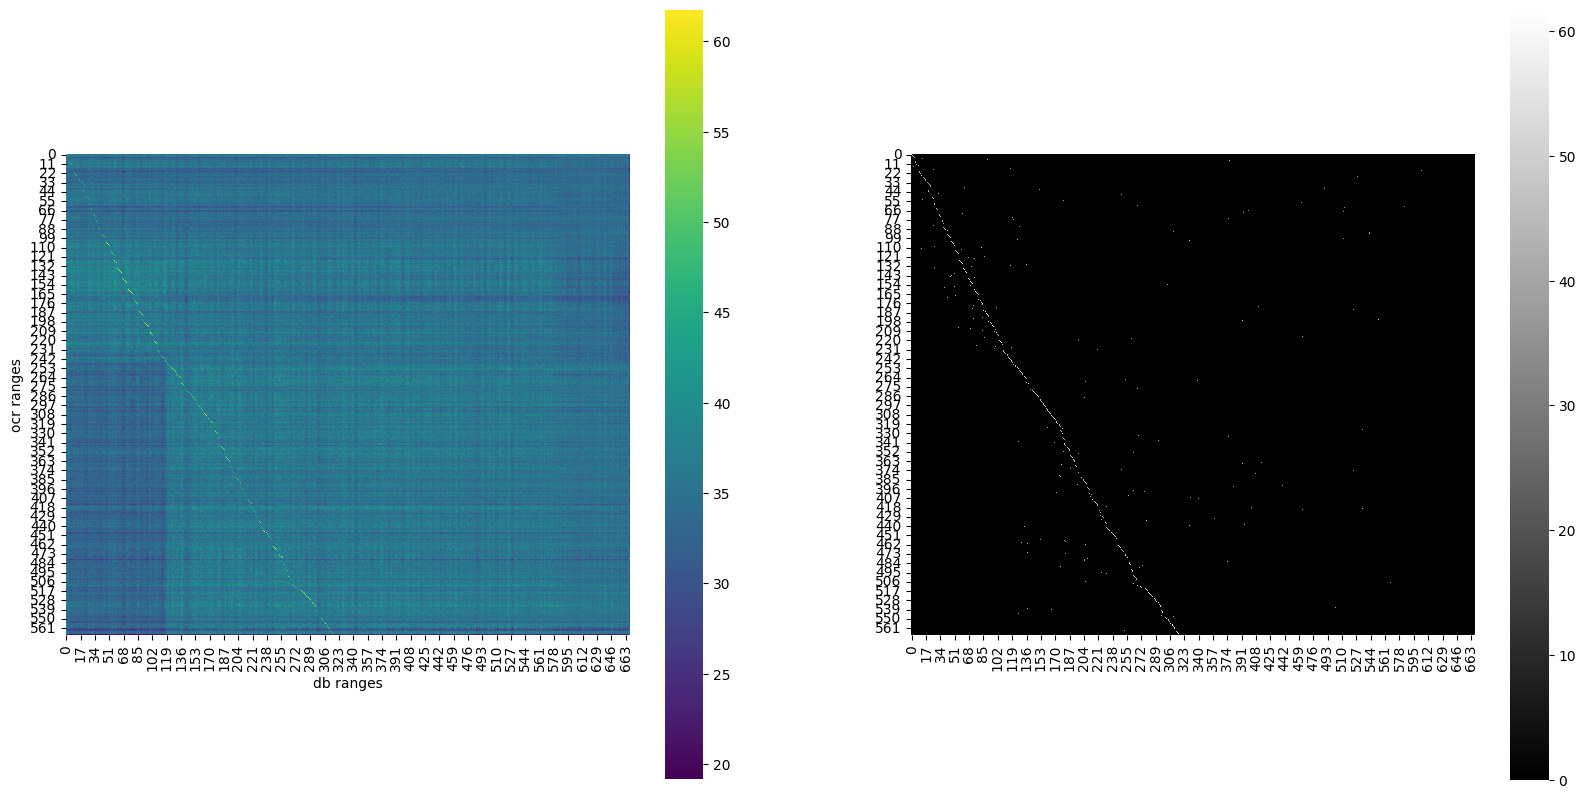

In [ ]:
range_len = 10
step = 5

db_rows = [*events.values()]
db_ranges = [(0+i, range_len+i) for i in range(0, len(db_rows), step)]

ocr_rows = []
for page in pages_str:
    ocr_rows += page
ocr_ranges = [(0+i, range_len+i) for i in range(0, len(ocr_rows), step)]

m = np.zeros(shape=(len(db_ranges), len(ocr_ranges)))
for i in range(len(db_ranges)):
    for j in range(len(ocr_ranges)):
        m[i, j] = fuzz.ratio(
            "\n".join(db_rows[
                slice(*db_ranges[i])
            ]),
            "\n".join(ocr_rows[
                slice(*ocr_ranges[j])
            ])
        )

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(m.T, ax=ax[0], square=True, cmap="viridis")
for x in m:
    x_argmax = x.argmax()
    x_max = x[x_argmax]
    x[:] = 0
    x[x_argmax] = x_max
sns.heatmap(m.T, ax=ax[1], square=True, cmap="gray")
ax[0].set_xlabel("db ranges")
ax[0].set_ylabel("ocr ranges")

In [109]:
db_rows[slice(*db_ranges[408])]

['22 11 p. Maria Christina Lovisasdr.   Luvia',
 '6 12 p. Gretha Lisa Isaksdr.   Sastmola',
 '6 12 tp.s. Jacob Vilhelm Johanss.   B.borgs L.förs.',
 '6 12 drg. Eric Johanss. Svartvik  Sideby',
 '6 12 ld.bd.s.\\Kicke admitt. Henric Michelss. Lagerberg  Sastmola',
 '6 12 p. Carolina Juliana Gustafsdr.   Björneborg',
 '6 12 Lindströms tp.d. Lovisa Pettersdr.   Norrmark',
 '6 12 Finbelås drg. Gustaf Mattss.   Norrmark',
 '15 12 Hurtig tp.s. Johan Vilhelm Davidss.   Norrmark',
 '0 0 sjöman Johan Joh.s. Bläcksten\\Keller Stenros  B.borgs L.förs.']